In [76]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.magics import display

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [77]:
df = pd.read_excel("medical_insurance.xlsx")

## 1-ci hissə — Dataset analizi

In [53]:
print("===== First 10 Rows =====")
display(df.head(10))

===== First 10 Rows =====


,Age,Height_cm,Weight_kg,BMI,Smoker,ExercisePerWeek,ChronicDisease,InsuranceCost_AZN
0,58,157,48,19.5,0,3,0,3286
1,65,156,114,46.8,0,6,0,9776
2,23,163,74,27.9,0,3,0,4747
3,46,187,80,22.9,0,2,0,4864
4,35,159,72,28.5,0,1,0,4259
5,24,172,89,30.1,0,0,0,2393
6,25,174,55,18.2,0,5,0,3271
7,22,152,129,55.8,0,4,0,10290
8,24,174,80,26.4,0,5,0,3439
9,40,163,130,48.9,0,1,0,6954


In [28]:
print("===== Last 10 Rows =====")
display(df.tail(10))

===== Last 10 Rows =====


,Age,Height_cm,Weight_kg,BMI,Smoker,ExercisePerWeek,ChronicDisease,InsuranceCost_AZN
490,46,179,85,26.5,No,1,No,2416
491,31,178,84,26.5,No,4,Yes,3290
492,28,193,83,22.3,Yes,3,No,4091
493,23,195,76,20.0,No,6,Yes,3207
494,37,166,67,24.3,Yes,6,No,4911
495,65,185,76,22.2,Yes,7,Yes,6937
496,25,150,52,23.1,Yes,2,Yes,6772
497,41,193,125,33.6,Yes,4,Yes,7752
498,22,162,127,48.4,No,2,Yes,6183
499,25,152,104,45.0,Yes,2,No,7531


In [29]:
print("Dataset Shape:", df.shape)
print("\nColumns:", list(df.columns))

Dataset Shape: (500, 8)

Columns: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Smoker', 'ExercisePerWeek', 'ChronicDisease', 'InsuranceCost_AZN']


In [30]:
print("===== Data Types =====")
print(df.dtypes)

===== Data Types =====
Age                    int64
Height_cm              int64
Weight_kg              int64
BMI                  float64
Smoker                   str
ExercisePerWeek        int64
ChronicDisease           str
InsuranceCost_AZN      int64
dtype: object


In [31]:
print("===== Statistics =====")
display(df.describe(include='all'))

===== Statistics =====


,Age,Height_cm,Weight_kg,BMI,Smoker,ExercisePerWeek,ChronicDisease,InsuranceCost_AZN
count,500.000000,500.000000,500.000000,500.000000,500,500.000000,500,500.000000
unique,NaN,NaN,NaN,NaN,2,NaN,2,NaN
top,NaN,NaN,NaN,NaN,No,NaN,Yes,NaN
freq,NaN,NaN,NaN,NaN,264,NaN,252,NaN
mean,43.730000,173.188000,88.710000,30.162400,NaN,3.520000,NaN,5060.124000
std,15.500504,13.460275,23.463652,9.450662,NaN,2.259161,NaN,2375.020457
min,18.000000,150.000000,45.000000,12.700000,NaN,0.000000,NaN,500.000000
25%,30.000000,161.000000,69.000000,22.800000,NaN,2.000000,NaN,3231.750000
50%,43.500000,173.500000,88.000000,30.100000,NaN,3.000000,NaN,5039.500000
75%,57.250000,185.000000,108.000000,36.125000,NaN,6.000000,NaN,6964.000000


In [32]:
print("===== Missing Values =====")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

===== Missing Values =====
Age                  0
Height_cm            0
Weight_kg            0
BMI                  0
Smoker               0
ExercisePerWeek      0
ChronicDisease       0
InsuranceCost_AZN    0
dtype: int64

Duplicate Rows: 0


## 2-ci hissə — Data Cleaning

In [33]:
# 1. Boş dəyərləri aşkar et
print('Doldurmadan əvvəl boş dəyərlər:')
print(df.isnull().sum())

Doldurmadan əvvəl boş dəyərlər:
Age                  0
Height_cm            0
Weight_kg            0
BMI                  0
Smoker               0
ExercisePerWeek      0
ChronicDisease       0
InsuranceCost_AZN    0
dtype: int64


In [34]:
# 2. Boş dəyərləri doldur

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object','string']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Doldurmadan sonra boş dəyərlər:",df.isnull().sum())

# Təkrar sətirləri silirik (varsa)
before = df.shape[0]
df= df.drop_duplicates().reset_index(drop=True)
print('Silinmiş təkrar sətir sayı:', before - df.shape[0])

Doldurmadan sonra boş dəyərlər: Age                  0
Height_cm            0
Weight_kg            0
BMI                  0
Smoker               0
ExercisePerWeek      0
ChronicDisease       0
InsuranceCost_AZN    0
dtype: int64
Silinmiş təkrar sətir sayı: 0


In [35]:
# 3. Outlier analizi
num_cols = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'ExercisePerWeek', 'InsuranceCost_AZN']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) & (df[col] > upper)).sum()

    print(f"{col}: {outliers} outlier")


Age: 0 outlier
Height_cm: 0 outlier
Weight_kg: 0 outlier
BMI: 0 outlier
ExercisePerWeek: 0 outlier
InsuranceCost_AZN: 0 outlier


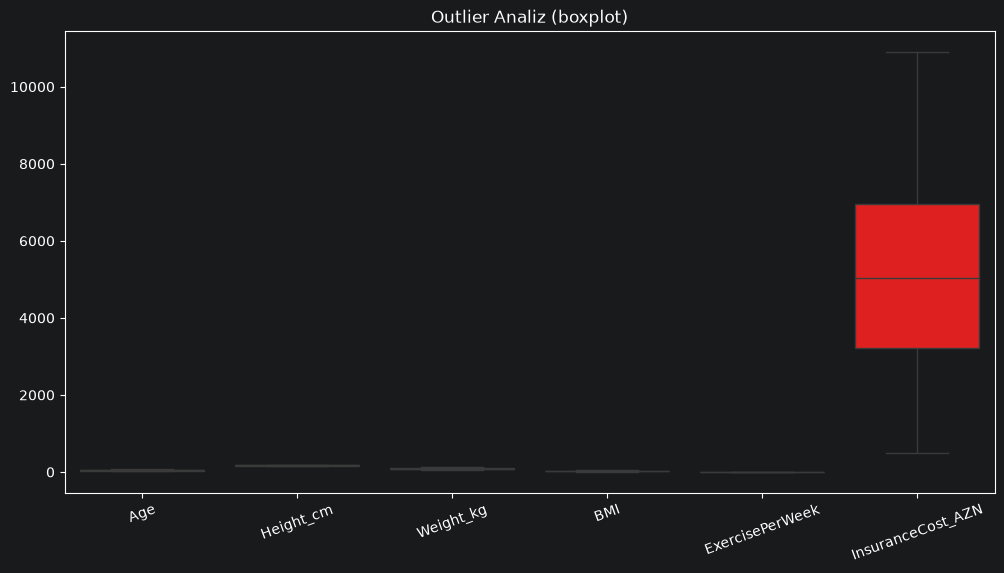

In [43]:
# Qrafik

plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number),color='red')
plt.title('Outlier Analiz (boxplot)')
plt.xticks(rotation=20)
plt.show()


In [63]:
# 4. Categorical sütunları model üçün uyğun formata çevir
encoder = LabelEncoder()

df["Smoker"]=encoder.fit_transform(df["Smoker"])
df["ChronicDisease"] = encoder.fit_transform(df["ChronicDisease"])

print('Çevirmədən sonra data tipləri:')
print(df.dtypes)
df.head()

Çevirmədən sonra data tipləri:
Age                    int64
Height_cm              int64
Weight_kg              int64
BMI                  float64
Smoker                 int64
ExercisePerWeek        int64
ChronicDisease         int64
InsuranceCost_AZN      int64
dtype: object
Çevirmədən sonra data tipləri:
Age                    int64
Height_cm              int64
Weight_kg              int64
BMI                  float64
Smoker                 int64
ExercisePerWeek        int64
ChronicDisease         int64
InsuranceCost_AZN      int64
dtype: object


,Age,Height_cm,Weight_kg,BMI,Smoker,ExercisePerWeek,ChronicDisease,InsuranceCost_AZN
0,58,157,48,19.5,0,3,0,3286
1,65,156,114,46.8,0,6,0,9776
2,23,163,74,27.9,0,3,0,4747
3,46,187,80,22.9,0,2,0,4864
4,35,159,72,28.5,0,1,0,4259


## 3-cü hissə — Feature və Target seçimi

In [66]:
target = "InsuranceCost_AZN"
features  = [c for c in df.columns if c!=target]

X = df[features]
y = df[target]


print('Target',target)
print('Feature-lar',features)
print('X ölçüsü:', X.shape, '| y ölçüsü:', y.shape)

Target InsuranceCost_AZN
Feature-lar ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Smoker', 'ExercisePerWeek', 'ChronicDisease']
X ölçüsü: (500, 7) | y ölçüsü: (500,)


## 4-cü hissə — Train/Test bölünməsi


In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('Train ölçüsü:', X_train.shape[0], 'sətir')
print('Test ölçüsü :', X_test.shape[0], 'sətir')

Train ölçüsü: 400 sətir
Test ölçüsü : 100 sətir


## 5-ci hissə — Decision Tree Regressor


In [83]:
params = {
    "criterion": ["squared_error", "absolute_error", "poisson"],
    "max_depth": [3,4,5,6,8,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,5]
}
dt = DecisionTreeRegressor(random_state=42)

grid_dt = GridSearchCV(
    dt,
    params,
    cv=5,
    n_jobs=-1,
    scoring="r2",
    error_score="raise"
)

grid_dt.fit(X_train, y_train)

print("En yaxsi parametrler:", grid_dt.best_params_)
print("CV R²:", round(grid_dt.best_score_,4))

best_dt = grid_dt.best_estimator_
prediction_dt = best_dt.predict(X_test)

En yaxsi parametrler: {'criterion': 'poisson', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV R²: 0.0636


## 6-cı hissə — Decision Tree qiymətləndirilməsi

In [85]:
mae = mean_absolute_error(y_test, prediction_dt)
mse = mean_squared_error(y_test, prediction_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, prediction_dt)

print("--- Decision Tree ---")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

--- Decision Tree ---
MAE: 1722.2799437356434
MSE: 4337681.8445092905
RMSE: 2082.7102161628945
R2: 0.19685846001297658


## 7-ci hissə — Random Forest Regressor


In [89]:
params_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 1.0],
}
rf = RandomForestRegressor(random_state=42)
grid_rf = GridSearchCV(rf,params_rf,cv=5,n_jobs=-1,scoring="r2")
grid_rf.fit(X_train, y_train)
print("En yaxsi parametrler:", grid_dt.best_params_)
print("CV R²:", round(grid_dt.best_score_,4))

best_rf = grid_rf.best_estimator_
prediction_rf = best_rf.predict(X_test)


En yaxsi parametrler: {'criterion': 'poisson', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV R²: 0.0636


## 8-ci hissə — Random Forest qiymətləndirilməsi


In [91]:
mae = mean_absolute_error(y_test,prediction_rf)
mse = mean_squared_error(y_test,prediction_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,prediction_rf)

print("--- Random Forest ---")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

--- Random Forest ---
MAE: 1652.885410817104
MSE: 4112189.2304376303
RMSE: 2027.8533552596032
R2: 0.2386094440208183


## 9-cu hissə — Modellərin müqayisəsi

In [95]:
comparison = pd.DataFrame({

    "Model":["Decision Tree","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,prediction_dt),
        mean_absolute_error(y_test,prediction_rf)
    ],
    "MSE":[
        mean_squared_error(y_test,prediction_dt),
        mean_squared_error(y_test,prediction_rf)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,prediction_dt)),
        np.sqrt(mean_squared_error(y_test,prediction_rf))
    ],
    "R2":[
        r2_score(y_test,prediction_dt),
        r2_score(y_test,prediction_rf)
    ]
})
print(comparison)

           Model          MAE           MSE         RMSE        R2
0  Decision Tree  1722.279944  4.337682e+06  2082.710216  0.196858
1  Random Forest  1652.885411  4.112189e+06  2027.853355  0.238609


## 10-cu hissə — Feature Importance

In [98]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_

})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)

           Feature  Importance
3              BMI    0.322007
2        Weight_kg    0.288505
1        Height_cm    0.161493
0              Age    0.156515
5  ExercisePerWeek    0.071481
4           Smoker    0.000000
6   ChronicDisease    0.000000


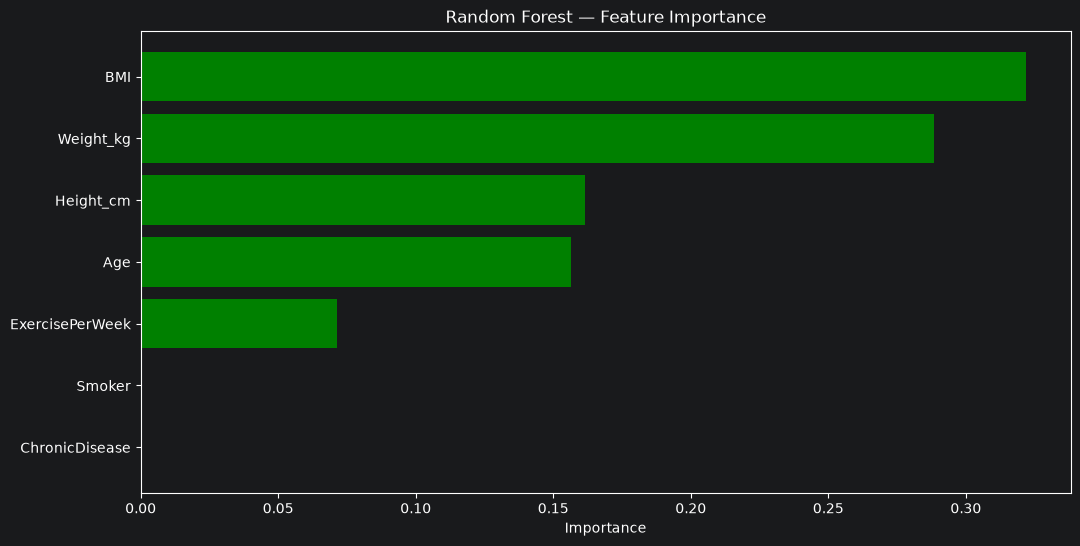

In [104]:
plt.figure(figsize=(12,6))
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.barh(
    importance["Feature"],
    importance["Importance"],
    color='green'
)
plt.gca().invert_yaxis()
plt.show()

In [105]:
print(importance.head(3))

     Feature  Importance
3        BMI    0.322007
2  Weight_kg    0.288505
1  Height_cm    0.161493


In [106]:
print(importance.tail(1))

          Feature  Importance
6  ChronicDisease         0.0


## 11-ci hissə — Yeni müştəri üçün proqnoz


In [107]:
new_customer = pd.DataFrame({
    "Age":[28],
    "Height_cm":[179],
    "Weight_kg":[45],
    "BMI":[14],
    "Smoker":[1],
    "ExercisePerWeek":[2],
    "ChronicDisease":[1]

})
prediction = best_rf.predict(new_customer)

print("InsuranceCost_AZN:",prediction)

InsuranceCost_AZN: [3637.26057555]


## Analiz sualları

1. **Decision Tree necə qərar verir?**
Məlumatı bölərək qərar verir.

2. **Random Forest niyə yaxşıdır?**
Çoxlu ağac istifadə edib səhvi azaldır.

3. **Ağac sayı artırsa nə olur?**
Stabillik artır, vaxt çoxalır.

4. **max_depth çox böyük olsa?**
Overfitting yarana bilər.

5. **min_samples_leaf təsiri?**
Artarsa model sadələşir.

6. **Feature Importance nədir?**
Vacib xüsusiyyətləri göstərir.

7. **Ən vacib feature?**
Smoker, çünki qiymətə çox təsir edir.

8. **BMI əlaqəsi?**
BMI artdıqca xərc artır.

9. **Siqaret təsiri?**
Qiyməti artırır.

10. **İdman təsiri?**
Qiyməti azalda bilər.

11. **Xroniki xəstəlik təsiri?**
Qiyməti artırır.

12. **Yeni məlumatlar?**
Qidalanma və tibbi tarix.